# Manual Bike-Share Analysis Notebook

This notebook is the starting point for the Session 2 workflow build.

It downloads the UCI Bike Sharing data directly, prepares a cleaned table in-place, explores high-demand hours, and writes a few outputs to fixed paths. It works, but it also mixes data download, preparation, analysis, and reporting inside one stateful document. That is exactly why we are going to convert it into a Python scripts based workflow.


## What This Notebook Is Trying To Answer

The guiding question for the analysis is:

> How do time-of-day and day type shape bike-share demand, and when do the highest-demand hours happen?

We will answer that question here in notebook form first. Later, we will keep the same question and the same outputs, but move the work into a clearer workflow structure.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data/raw")
RESULTS_DIR = Path("results")

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ARCHIVE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
ARCHIVE_PATH = DATA_DIR / "Bike-Sharing-Dataset.zip"
CSV_PATH = DATA_DIR / "hour.csv"


## Step 1: Download the Data Manually

In notebook form, the data download happens right here in the analysis. That is convenient in the moment, but it also means the notebook is responsible for both acquisition and analysis.


In [2]:
print(f"Downloading {ARCHIVE_URL}")
urlretrieve(ARCHIVE_URL, ARCHIVE_PATH)

with ZipFile(ARCHIVE_PATH) as zf:
    with zf.open("hour.csv") as src, CSV_PATH.open("wb") as dst:
        dst.write(src.read())

print(f"Wrote {ARCHIVE_PATH}")
print(f"Wrote {CSV_PATH}")


Wrote data/raw/Bike-Sharing-Dataset.zip
Wrote data/raw/hour.csv


## Step 2: Load the Raw Hourly Table

Once the archive is unpacked, we can read `hour.csv` directly.


In [3]:
raw = pd.read_csv(CSV_PATH, parse_dates=["dteday"])
raw.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Step 3: Prepare the Data Inside the Notebook

This is where the notebook starts doing real workflow work. We decode a few categorical columns, convert the normalized weather values into human-readable units, and build a cleaned analysis table.


In [4]:
season_map = {1: "winter", 2: "spring", 3: "summer", 4: "fall"}
weather_map = {
    1: "clear",
    2: "mist_cloud",
    3: "light_rain_or_snow",
    4: "heavy_rain_or_snow",
}
day_type_map = {0: "non_working_day", 1: "working_day"}

prepared = (
    raw.rename(columns={"dteday": "date", "cnt": "total_rentals"})
    .assign(
        season=lambda x: x["season"].map(season_map),
        weather=lambda x: x["weathersit"].map(weather_map),
        day_type=lambda x: x["workingday"].map(day_type_map),
        temp_c=lambda x: x["temp"] * 47 - 8,
        feels_like_c=lambda x: x["atemp"] * 66 - 16,
        humidity_pct=lambda x: x["hum"] * 100,
        windspeed_kph=lambda x: x["windspeed"] * 67,
    )
    .loc[:, [
        "date",
        "hr",
        "season",
        "mnth",
        "weekday",
        "holiday",
        "workingday",
        "day_type",
        "weather",
        "temp_c",
        "feels_like_c",
        "humidity_pct",
        "windspeed_kph",
        "casual",
        "registered",
        "total_rentals",
    ]]
    .rename(columns={"hr": "hour", "mnth": "month"})
)

prepared.head()


,date,hour,season,month,weekday,holiday,workingday,day_type,weather,temp_c,feels_like_c,humidity_pct,windspeed_kph,casual,registered,total_rentals
0,2011-01-01,0,winter,1,6,0,0,non_working_day,clear,3.28,3.0014,81.0,0.0,3,13,16
1,2011-01-01,1,winter,1,6,0,0,non_working_day,clear,2.34,1.9982,80.0,0.0,8,32,40
2,2011-01-01,2,winter,1,6,0,0,non_working_day,clear,2.34,1.9982,80.0,0.0,5,27,32
3,2011-01-01,3,winter,1,6,0,0,non_working_day,clear,3.28,3.0014,75.0,0.0,3,10,13
4,2011-01-01,4,winter,1,6,0,0,non_working_day,clear,3.28,3.0014,75.0,0.0,0,1,1


## Step 4: Define High-Demand Hours

Here I am choosing the high-demand threshold directly in the notebook. That is a perfectly normal exploratory move, but it is one of the settings we will later want to move into config.


In [5]:
HIGH_DEMAND_QUANTILE = 0.90
high_demand_cutoff = prepared["total_rentals"].quantile(HIGH_DEMAND_QUANTILE)
prepared["is_high_demand"] = prepared["total_rentals"] >= high_demand_cutoff

high_demand_cutoff


np.float64(451.2000000000007)

## Step 5: Build the Summary Tables

These are the main analysis outputs we care about for the workshop. One table shows mean rentals by hour and day type. Another shows how often each hour lands in the high-demand slice.


In [6]:
hourly_profile = (
    prepared.groupby(["hour", "day_type"], as_index=False)["total_rentals"]
    .mean()
    .rename(columns={"total_rentals": "mean_rentals"})
)

high_demand_share_by_hour = (
    prepared.groupby("hour", as_index=False)["is_high_demand"]
    .mean()
    .rename(columns={"is_high_demand": "high_demand_share"})
)

weather_summary = (
    prepared.groupby("weather", as_index=False)
    .agg(
        mean_rentals=("total_rentals", "mean"),
        observations=("total_rentals", "size"),
    )
    .sort_values("mean_rentals", ascending=False)
)

hourly_profile.head()


,hour,day_type,mean_rentals
0,0,non_working_day,90.800000
1,0,working_day,36.786290
2,1,non_working_day,69.508696
3,1,working_day,16.552632
4,2,non_working_day,53.171053


## Step 6: Plot the Results

This is the reporting part of the notebook. It still works, but it also means the notebook now owns plotting, output naming, and figure state as well as the analysis itself.


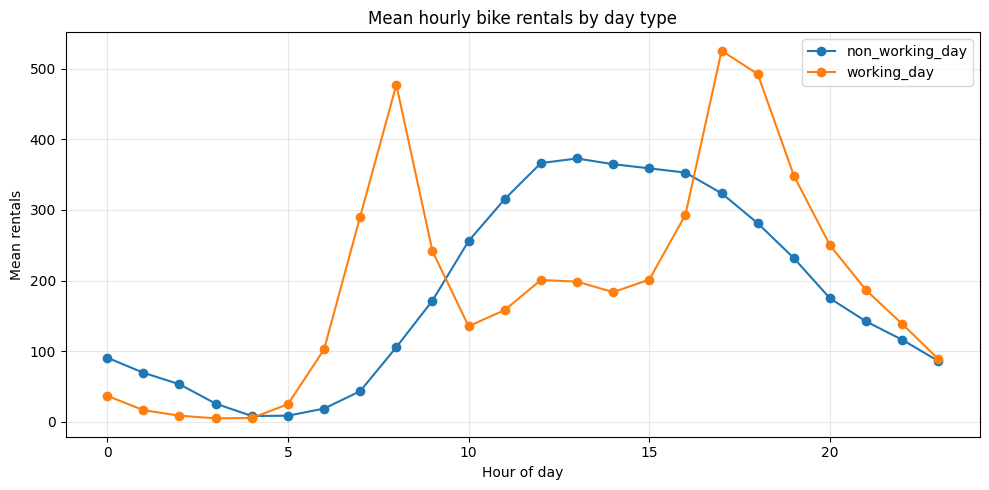

In [7]:
fig1, ax = plt.subplots(figsize=(10, 5))

for day_type, group in hourly_profile.groupby("day_type"):
    ax.plot(group["hour"], group["mean_rentals"], marker="o", label=day_type)

ax.set_title("Mean hourly bike rentals by day type")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean rentals")
ax.legend()
ax.grid(alpha=0.3)
fig1.tight_layout()
plt.show()


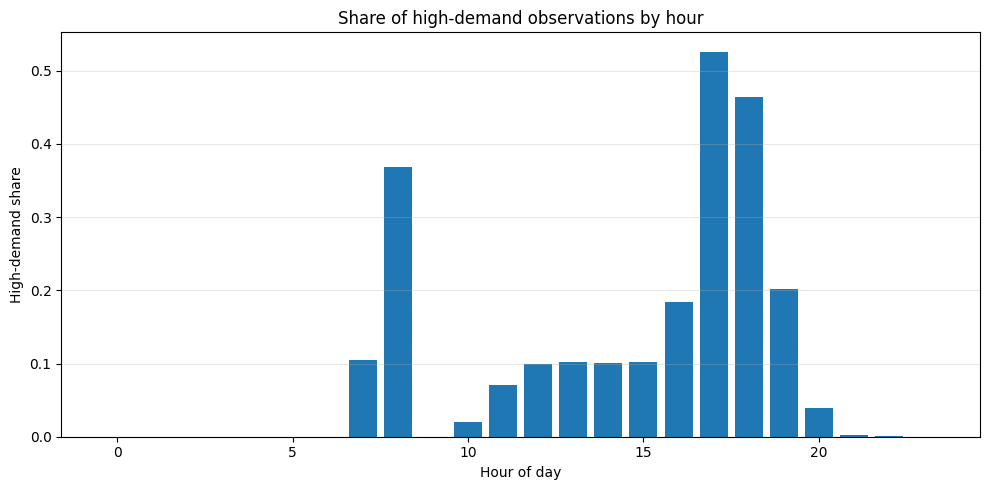

In [8]:
fig2, ax = plt.subplots(figsize=(10, 5))
ax.bar(high_demand_share_by_hour["hour"], high_demand_share_by_hour["high_demand_share"])
ax.set_title("Share of high-demand observations by hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("High-demand share")
ax.grid(axis="y", alpha=0.3)
fig2.tight_layout()
plt.show()


## Step 7: Write Fixed Outputs

This final cell writes the tables and plots to fixed locations under `results/`.

It is also a good example of a notebook limitation: this cell depends on state created by earlier cells, including `hourly_profile`, `high_demand_share_by_hour`, `fig1`, and `fig2`. If you run cells out of order, the notebook can fail in ways that are easy to miss.


In [9]:
HOURLY_PROFILE_PATH = RESULTS_DIR / "hourly_profile.csv"
HIGH_DEMAND_SHARE_PATH = RESULTS_DIR / "high_demand_share_by_hour.csv"
WEATHER_SUMMARY_PATH = RESULTS_DIR / "weather_summary.csv"
FIGURE_ONE_PATH = RESULTS_DIR / "hourly_demand_by_day_type.png"
FIGURE_TWO_PATH = RESULTS_DIR / "high_demand_share_by_hour.png"

hourly_profile.to_csv(HOURLY_PROFILE_PATH, index=False)
high_demand_share_by_hour.to_csv(HIGH_DEMAND_SHARE_PATH, index=False)
weather_summary.to_csv(WEATHER_SUMMARY_PATH, index=False)

fig1.savefig(FIGURE_ONE_PATH, dpi=150)
fig2.savefig(FIGURE_TWO_PATH, dpi=150)

print(f"Wrote {HOURLY_PROFILE_PATH}")
print(f"Wrote {HIGH_DEMAND_SHARE_PATH}")
print(f"Wrote {WEATHER_SUMMARY_PATH}")
print(f"Wrote {FIGURE_ONE_PATH}")
print(f"Wrote {FIGURE_TWO_PATH}")


Wrote results/hourly_profile.csv
Wrote results/high_demand_share_by_hour.csv
Wrote results/weather_summary.csv
Wrote results/hourly_demand_by_day_type.png
Wrote results/high_demand_share_by_hour.png


## Why We Are Converting This Notebook

This notebook is useful because it proves the analysis idea is worth keeping. It also makes the workflow weaknesses easy to see:

- the data download happens inside the notebook instead of in a separate fetch step
- parameters such as `HIGH_DEMAND_QUANTILE` are hard-coded in the document
- outputs are always written to the same fixed filenames
- the notebook depends on execution order and in-memory state
- there is no copied config, run log, or run directory for one execution

When we convert this into a scripts-based workflow, we gain clearer stage boundaries, config-driven behavior, durable logs, and per-run output folders.

And even after that conversion, there is still more we can do. Once the workflow is structured, we can add tests, multiruns, experiment tracking, or stronger orchestration without changing the underlying analysis question.
